# 📊 Day 16 — Feature Engineering
### 100 Days of Data Science | by Shoaib Aslam

---

## Table of Contents

1️⃣ What is Feature Engineering  
2️⃣ Why Feature Engineering Matters  
3️⃣ Loading the Dataset  
4️⃣ Creating New Features  
5️⃣ Encoding Categorical Features  
6️⃣ Binning (Bucketing) Numerical Features  
7️⃣ Feature Scaling  
8️⃣ Handling Date & Text Features  
9️⃣ Feature Selection  
🔟 When to Use What  

---
## 1️⃣ What is Feature Engineering?

Feature Engineering is the process of **using raw data to create new features** that make machine learning models perform better.

It involves:
- Creating new columns from existing ones
- Transforming raw values into more useful formats
- Encoding categories into numbers
- Scaling values to the same range

> **Key idea:** Better features = better model. Feature engineering often matters more than the choice of algorithm.

---
## 2️⃣ Why Feature Engineering Matters?

| Without Feature Engineering | With Feature Engineering |
|------------------------------|---------------------------|
| Raw text columns unusable by ML | Encoded into numbers |
| Wide value ranges confuse models | Scaled to same range |
| Hidden patterns in raw data | Extracted into new features |
| Weak model performance | Significantly improved accuracy |
| Irrelevant features slow down training | Only best features kept |

---
## 3️⃣ Loading the Dataset

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler

sns.set_style('whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Winemag dataset
df = pd.read_csv(r"C:\Users\aslam\Downloads\winemag-data-130k-v2.csv\winemag-data-130k-v2.csv", index_col=0)
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [3]:
# Keep relevant columns and clean missing values
df = df[['country', 'points', 'price', 'variety', 'winery', 'title']].dropna(subset=['points', 'price', 'country', 'variety'])

print("Shape:", df.shape)
df.head()

Shape: (120915, 6)


,country,points,price,variety,winery,title
1,Portugal,87,15.0,Portuguese Red,Quinta dos Avidagos,Quinta dos Avidagos 2011 Avidagos Red (Douro)
2,US,87,14.0,Pinot Gris,Rainstorm,Rainstorm 2013 Pinot Gris (Willamette Valley)
3,US,87,13.0,Riesling,St. Julian,St. Julian 2013 Reserve Late Harvest Riesling ...
4,US,87,65.0,Pinot Noir,Sweet Cheeks,Sweet Cheeks 2012 Vintner's Reserve Wild Child...
5,Spain,87,15.0,Tempranillo-Merlot,Tandem,Tandem 2011 Ars In Vitro Tempranillo-Merlot (N...


---
## 4️⃣ Creating New Features

New features are created by combining or transforming existing columns.

In [4]:
# Feature 1 — Value Score (points per dollar)
# Higher value score = more points per dollar spent
df['value_score'] = df['points'] / df['price']
df['value_score'] = df['value_score'].round(2)

print("Best value wines (highest points per dollar):")
df[['points', 'price', 'value_score']].sort_values('value_score', ascending=False).head(5)

Best value wines (highest points per dollar):


,points,price,value_score
126096,86,4.0,21.50
64590,86,4.0,21.50
20484,85,4.0,21.25
1987,85,4.0,21.25
29553,84,4.0,21.00


In [5]:
# Feature 2 — Is Premium (binary flag)
# 1 = premium wine (90+ points), 0 = regular wine
df['is_premium'] = (df['points'] >= 90).astype(int)

print("Premium wines:", df['is_premium'].sum())
print("Regular wines:", (df['is_premium'] == 0).sum())

Premium wines: 45373
Regular wines: 75542


In [6]:
# Feature 3 — Is Affordable (binary flag)
# 1 = affordable (price < 20), 0 = expensive
df['is_affordable'] = (df['price'] < 20).astype(int)

print("Affordable wines:", df['is_affordable'].sum())
print("Expensive wines:", (df['is_affordable'] == 0).sum())

Affordable wines: 39383
Expensive wines: 81532


In [7]:
# Feature 4 — Price per Point (cost efficiency)
df['price_per_point'] = (df['price'] / df['points']).round(2)

df[['points', 'price', 'price_per_point']].head(5)

,points,price,price_per_point
1,87,15.0,0.17
2,87,14.0,0.16
3,87,13.0,0.15
4,87,65.0,0.75
5,87,15.0,0.17


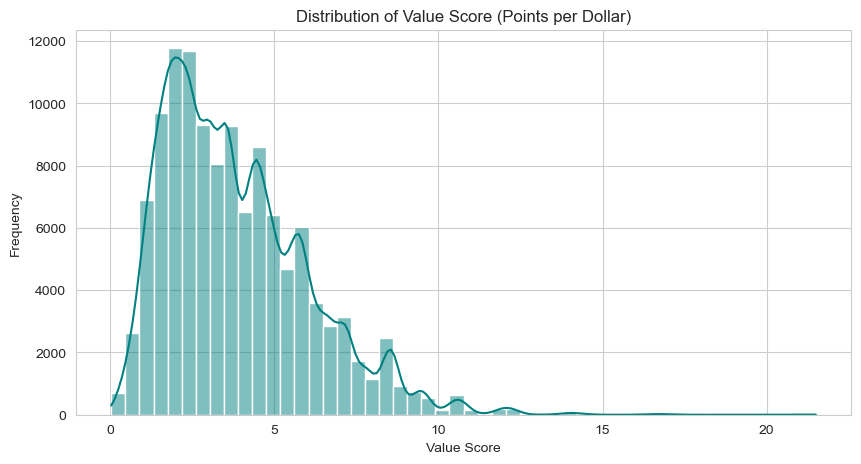

In [8]:
# Visualize value score distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['value_score'], bins=50, kde=True, color='teal')
plt.title("Distribution of Value Score (Points per Dollar)")
plt.xlabel("Value Score")
plt.ylabel("Frequency")
plt.show()

---
## 5️⃣ Encoding Categorical Features

Machine learning models only understand numbers — so we convert text categories into numbers.

In [9]:
# Check top countries
print("Unique countries:", df['country'].nunique())
df['country'].value_counts().head(5)

Unique countries: 42


country
US          54265
France      17776
Italy       16914
Spain        6573
Portugal     4875
Name: count, dtype: int64

In [10]:
# Method 1 — Label Encoding
# Converts each category to a unique integer
# Best for: ordinal categories (low, medium, high)

le = LabelEncoder()
df['country_encoded'] = le.fit_transform(df['country'])

print("Original vs Encoded:")
df[['country', 'country_encoded']].drop_duplicates().head(8)

Original vs Encoded:


,country,country_encoded
1,Portugal,30
2,US,39
5,Spain,36
6,Italy,21
7,France,14
8,Germany,16
16,Argentina,0
36,Chile,8


In [11]:
# Method 2 — One-Hot Encoding
# Creates a new binary column for each category
# Best for: nominal categories (no order, e.g. country names)

top5_countries = df['country'].value_counts().head(5).index
df_top5 = df[df['country'].isin(top5_countries)].copy()

ohe = pd.get_dummies(df_top5['country'], prefix='country')
print("One-Hot Encoded columns:", ohe.columns.tolist())
ohe.head()

One-Hot Encoded columns: ['country_France', 'country_Italy', 'country_Portugal', 'country_Spain', 'country_US']


,country_France,country_Italy,country_Portugal,country_Spain,country_US
1,False,False,True,False,False
2,False,False,False,False,True
3,False,False,False,False,True
4,False,False,False,False,True
5,False,False,False,True,False


#### 💡 Tip — Label vs One-Hot Encoding

| Method | When to Use | Example |
|--------|-------------|--------|
| Label Encoding | Ordinal categories (order matters) | Low=0, Medium=1, High=2 |
| One-Hot Encoding | Nominal categories (no order) | Country, Variety, Color |

---
## 6️⃣ Binning (Bucketing) Numerical Features

Binning converts a continuous number into a meaningful category.

In [12]:
# Bin wine points into quality tiers
bins = [79, 84, 89, 94, 100]
labels = ['Good', 'Very Good', 'Excellent', 'Outstanding']

df['quality_tier'] = pd.cut(df['points'], bins=bins, labels=labels)

print("Quality Tier Distribution:")
df['quality_tier'].value_counts()

Quality Tier Distribution:


quality_tier
Very Good      63712
Excellent      43162
Good           11830
Outstanding     2211
Name: count, dtype: int64

In [13]:
# Bin wine price into price segments
price_bins = [0, 15, 30, 60, 100, 10000]
price_labels = ['Budget', 'Affordable', 'Mid-Range', 'Premium', 'Luxury']

df['price_segment'] = pd.cut(df['price'], bins=price_bins, labels=price_labels)

print("Price Segment Distribution:")
df['price_segment'].value_counts()

Price Segment Distribution:


price_segment
Affordable    48311
Mid-Range     34271
Budget        25095
Premium        9872
Luxury         3366
Name: count, dtype: int64

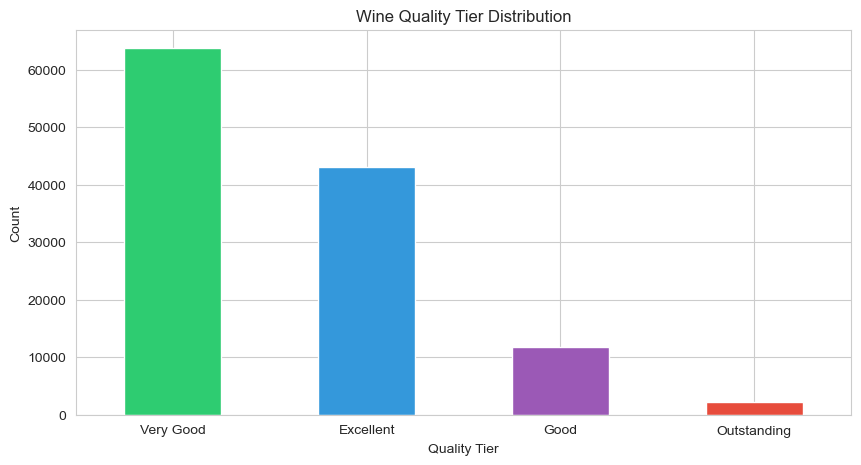

In [14]:
# Visualize quality tiers
plt.figure(figsize=(10, 5))
df['quality_tier'].value_counts().plot(kind='bar', color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c'])
plt.title("Wine Quality Tier Distribution")
plt.xlabel("Quality Tier")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

---
## 7️⃣ Feature Scaling

Scaling ensures all features are on the same scale so no single feature dominates the model.

In [15]:
# Before scaling — check ranges
print("Points range:", df['points'].min(), "-", df['points'].max())
print("Price range:", df['price'].min(), "-", df['price'].max())

Points range: 80 - 100
Price range: 4.0 - 3300.0


In [17]:
# Method 1 — Min-Max Scaling (Normalization)
scaler_minmax = MinMaxScaler()

df['points_normalized'] = scaler_minmax.fit_transform(df[['points']]).flatten()
df['price_normalized'] = scaler_minmax.fit_transform(df[['price']]).flatten()

print("Normalized Points range:", round(df['points_normalized'].min(), 2), "-", round(df['points_normalized'].max(), 2))
print("Normalized Price range:", round(df['price_normalized'].min(), 2), "-", round(df['price_normalized'].max(), 2))

Normalized Points range: 0.0 - 1.0
Normalized Price range: 0.0 - 1.0


In [19]:
# Method 2 — Standard Scaling (Standardization)
scaler_std = StandardScaler()

df['points_standardized'] = scaler_std.fit_transform(df[['points']]).flatten()
df['price_standardized'] = scaler_std.fit_transform(df[['price']]).flatten()

print("Standardized Points — Mean:", round(df['points_standardized'].mean(), 2), "| Std:", round(df['points_standardized'].std(), 2))
print("Standardized Price  — Mean:", round(df['price_standardized'].mean(), 2), "| Std:", round(df['price_standardized'].std(), 2))

Standardized Points — Mean: 0.0 | Std: 1.0
Standardized Price  — Mean: 0.0 | Std: 1.0


#### 💡 Tip — MinMax vs Standard Scaling

| Method | Output Range | When to Use |
|--------|-------------|-------------|
| Min-Max Scaling | 0 to 1 | Neural networks, KNN, image data |
| Standard Scaling | Mean=0, Std=1 | Linear regression, SVM, most ML models |

---
## 8️⃣ Handling Date & Text Features

Extracting useful information from text columns.

In [20]:
# Extract vintage year from wine title
# Most wine titles contain a year like: "Nicosia 2013 Vulkà Bianco"
df['vintage_year'] = df['title'].str.extract(r'(\b\d{4}\b)').astype(float)

print("Vintage year sample:")
df[['title', 'vintage_year']].dropna().head(5)

Vintage year sample:


,title,vintage_year
1,Quinta dos Avidagos 2011 Avidagos Red (Douro),2011.0
2,Rainstorm 2013 Pinot Gris (Willamette Valley),2013.0
3,St. Julian 2013 Reserve Late Harvest Riesling ...,2013.0
4,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,2012.0
5,Tandem 2011 Ars In Vitro Tempranillo-Merlot (N...,2011.0


In [21]:
# Feature — Wine age (assuming current year is 2025)
df['wine_age'] = 2025 - df['vintage_year']

print("Wine age distribution:")
df['wine_age'].describe()

Wine age distribution:


count    116778.000000
mean         13.872750
std          57.707022
min       -5175.000000
25%          12.000000
50%          14.000000
75%          16.000000
max        1025.000000
Name: wine_age, dtype: float64

---
## 9️⃣ Feature Selection

Not all features help the model. Keeping only the best ones improves performance and reduces noise.

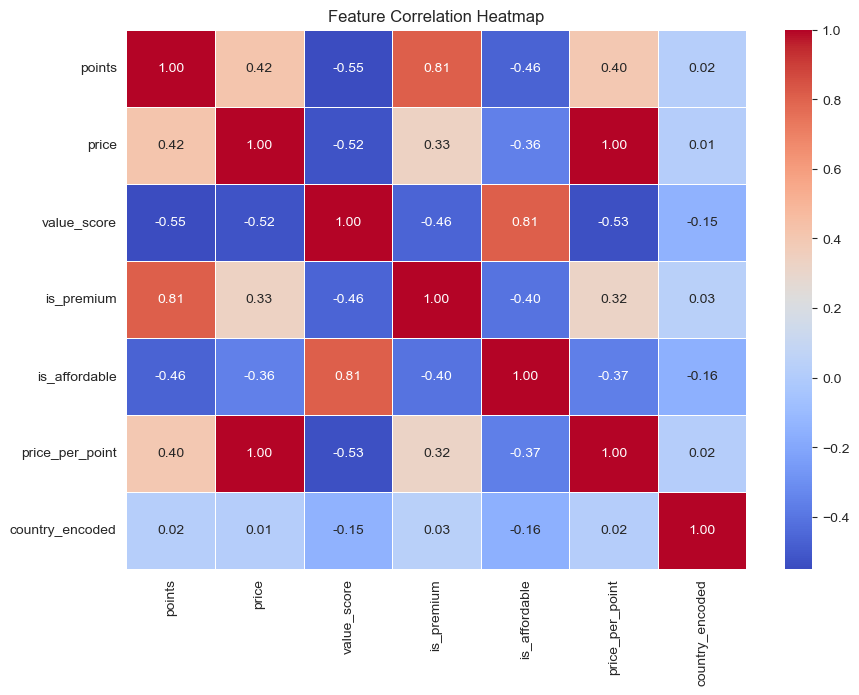

In [26]:
# Correlation of new features with price
feature_cols = ['points', 'price', 'value_score', 'is_premium', 'is_affordable', 'price_per_point', 'country_encoded']
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

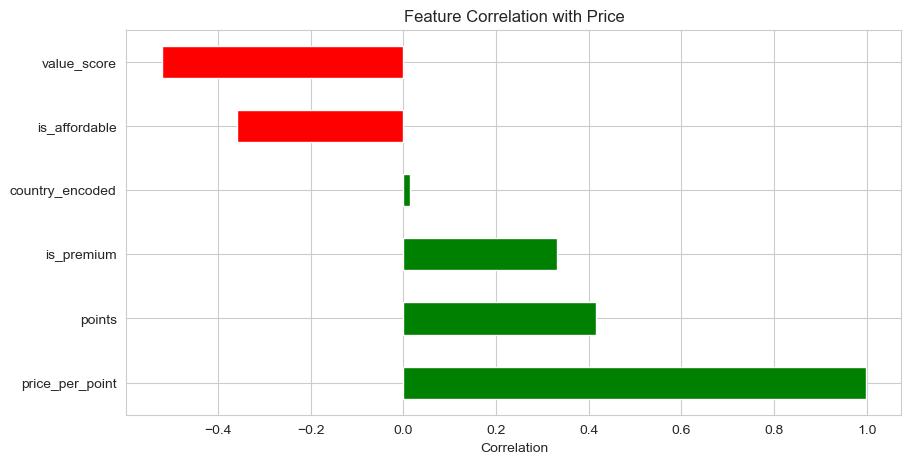

In [27]:
# Correlation with price — sorted
price_corr = df[feature_cols].corr()['price'].drop('price').sort_values(ascending=False)

plt.figure(figsize=(10, 5))
price_corr.plot(kind='barh', color=['green' if x > 0 else 'red' for x in price_corr])
plt.title("Feature Correlation with Price")
plt.xlabel("Correlation")
plt.show()

In [28]:
# Final engineered dataset overview
final_features = ['points', 'price', 'value_score', 'is_premium', 'is_affordable',
                  'price_per_point', 'country_encoded', 'quality_tier', 'price_segment']

print("Final Feature Set Shape:", df[['points', 'price', 'value_score', 'is_premium',
                                      'is_affordable', 'price_per_point', 'country_encoded']].shape)
df[['points', 'price', 'value_score', 'is_premium', 'quality_tier', 'price_segment']].head(5)

Final Feature Set Shape: (120915, 7)


,points,price,value_score,is_premium,quality_tier,price_segment
1,87,15.0,5.80,0,Very Good,Budget
2,87,14.0,6.21,0,Very Good,Budget
3,87,13.0,6.69,0,Very Good,Budget
4,87,65.0,1.34,0,Very Good,Premium
5,87,15.0,5.80,0,Very Good,Budget


---
## 🔟 When to Use What

| Technique | When to Use | Example |
|-----------|-------------|--------|
| Create new feature | Hidden relationship in raw data | points / price = value score |
| Binary flag | Yes/no condition | is_premium, is_affordable |
| Label Encoding | Ordinal categories | Low=0, Medium=1, High=2 |
| One-Hot Encoding | Nominal categories | Country, Variety |
| Binning | Convert number to category | Points → Good / Excellent |
| Min-Max Scaling | Neural networks, KNN | Scale 80-100 to 0-1 |
| Standard Scaling | Linear models, SVM | Mean=0, Std=1 |
| Text extraction | Date or info in text | Year from wine title |
| Feature selection | Remove irrelevant features | Keep high correlation only |

---
## 🔑 Key Takeaways

→ Feature engineering often improves model performance more than changing the algorithm  
→ Always create features that make business sense — not just statistical noise  
→ Label Encoding for ordinal, One-Hot Encoding for nominal categories  
→ Always scale features before training distance-based models like KNN or SVM  
→ Use Min-Max for neural networks, Standard Scaling for most other ML models  
→ Correlation heatmap is your best friend for feature selection  
→ Text columns contain hidden features — always try to extract them

---
## 📁 Connect & Follow the Journey

| Platform | Link |
|----------|------|
| 🐙 GitHub | https://github.com/imshoaibaslam/100-Days-of-Data-Science |
| 📊 Kaggle | https://www.kaggle.com/shoaib32922 |

---
*Day 16 of 100 — Keep Learning, Keep Building 🚀*